# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5.** Поиск типичных подпоследовательностей временного ряда.

### Подготовка окружения и ноутбука

In [1]:
import os
from pathlib import Path

practice_dir_path = Path(os.getcwd()).absolute()
print(practice_dir_path)

os.chdir(practice_dir_path)

c:\Users\admin\Projects\labs\5\3\tsc\practice\05 Snippets


In [2]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [3]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from stumpy import snippets
from sklearn.metrics import accuracy_score

from modules.snippets import *

c:\Users\admin\Projects\labs\5\3\tsc\.venv\Lib\site-packages\stumpy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


### **5.1.** Поиск сниппетов

#### **5.1.1**. Задача 1. Поиск сниппетов одномерного временного ряда

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

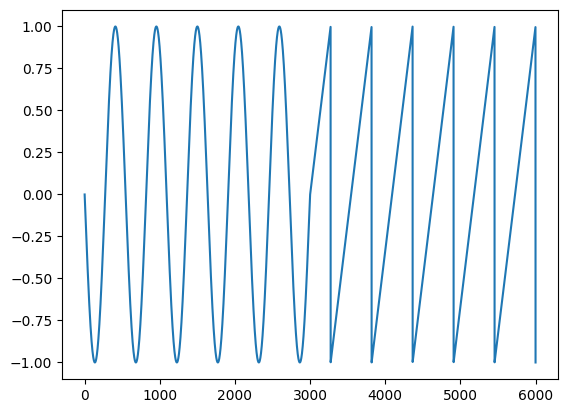

In [4]:
# Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [5]:
# Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


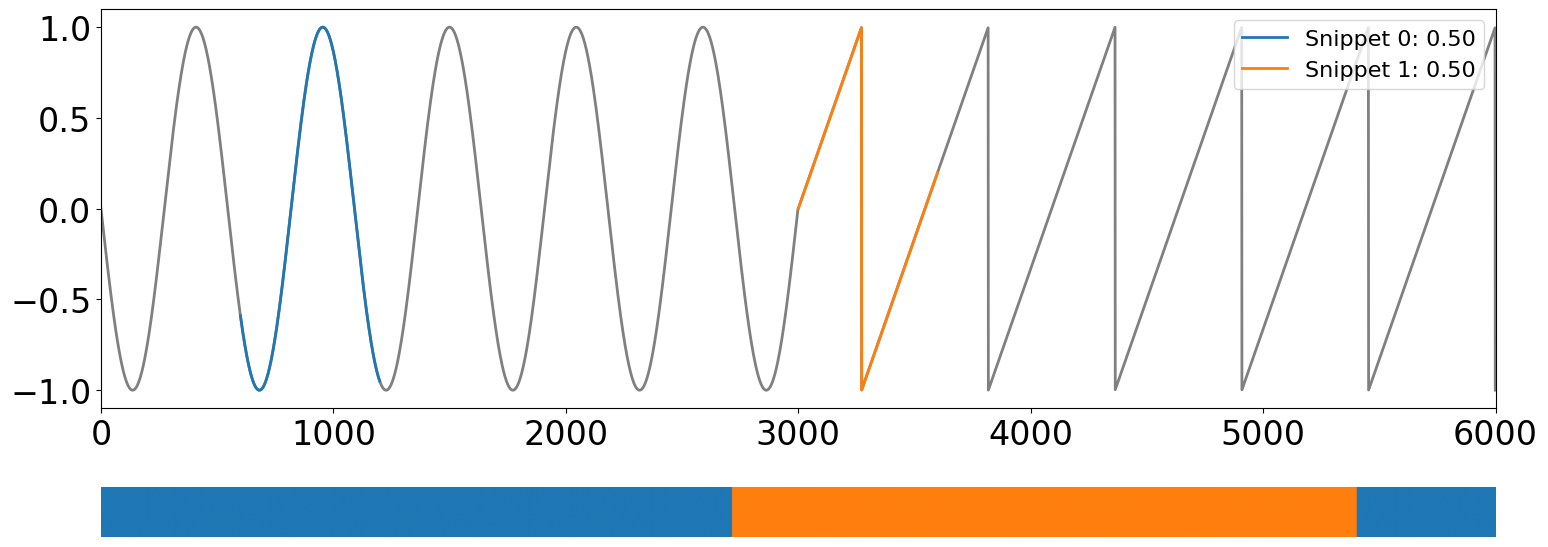

<Axes: >

In [6]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [7]:
pamap = np.loadtxt('./datasets/PAMAP/PAMAP.txt')

start = 1790
end = 1930

timestamp = pamap[0]
interval_mask = (timestamp >= start) & (timestamp <= end)

gyroscope = pamap[11][interval_mask]

In [8]:
snp = snippets(gyroscope, 600, 5, percentage=0.5)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


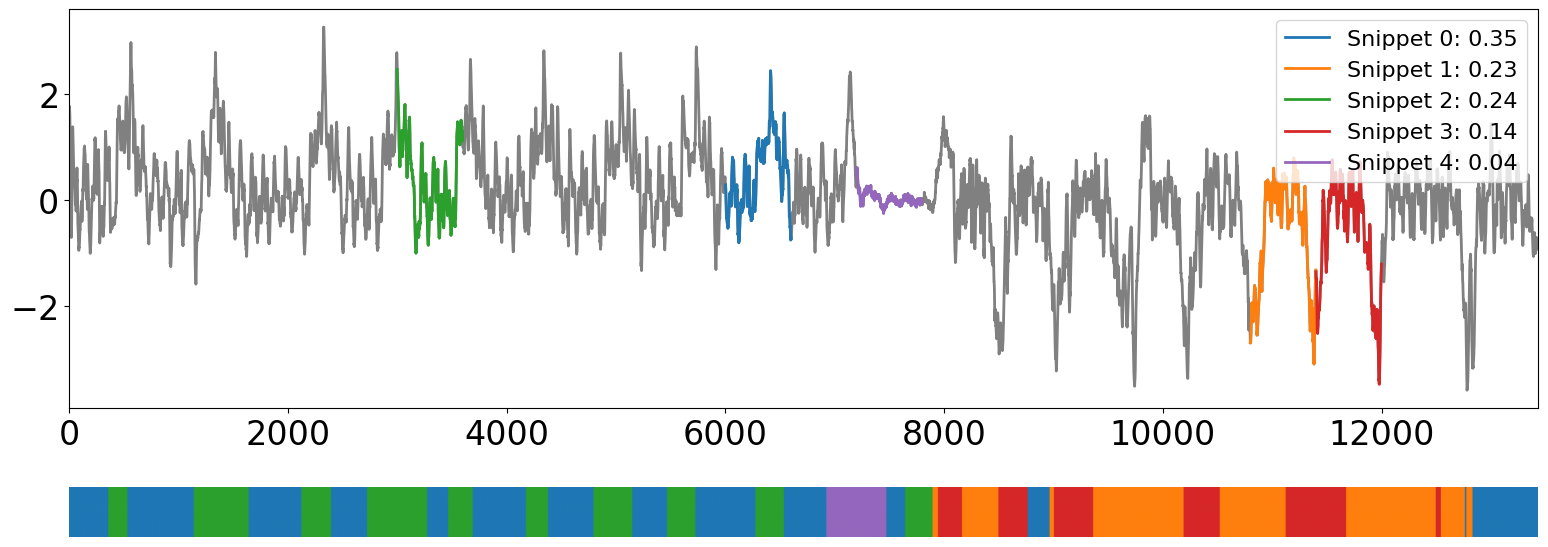

<Axes: >

In [9]:
plot_snippets(gyroscope, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [10]:
activity_ids = pamap[1]
activity_ids = activity_ids[interval_mask]
activity_ids -= activity_ids.min()

snp_activity_ids = np.zeros(len(activity_ids))
for value, start, end in snp[-1]:
    snp_activity_ids[start:end] = value

accuracy = accuracy_score(activity_ids, snp_activity_ids)
print(f"accuracy={accuracy*100:.2f}%")

accuracy=53.16%


In [11]:
mx = np.arange(500, 1000, 100).astype(int)
kx = np.arange(1, 10, 1).astype(int)

mk_accuracies = []

for m in mx:
    for k in kx:
        snp = snippets(gyroscope, m, k, percentage=0.5)
        snp_activity_ids = np.zeros(len(activity_ids))
        for value, start, end in snp[-1]:
            snp_activity_ids[start:end] = value
        accuracy = accuracy_score(activity_ids, snp_activity_ids)
        mk_accuracies.append((m, k, accuracy))
        print(f"m={m}, k={k}, accuracy={accuracy*100:.2f}%")

mk_accuracies = np.array(mk_accuracies)
best_idx = np.argmax(mk_accuracies[:, 2])
best_m = mk_accuracies[best_idx, 0]
best_k = mk_accuracies[best_idx, 1]
best_accuracy = mk_accuracies[best_idx, 2]
print(f"Best m={best_m}, k={best_k}, accuracy={best_accuracy*100:.2f}%")

m=500, k=1, accuracy=56.11%
m=500, k=2, accuracy=77.18%
m=500, k=3, accuracy=57.56%
m=500, k=4, accuracy=45.21%
m=500, k=5, accuracy=37.01%
m=500, k=6, accuracy=36.25%
m=500, k=7, accuracy=33.20%
m=500, k=8, accuracy=26.65%
m=500, k=9, accuracy=22.11%
m=600, k=1, accuracy=56.11%
m=600, k=2, accuracy=86.35%
m=600, k=3, accuracy=66.92%
m=600, k=4, accuracy=53.82%
m=600, k=5, accuracy=53.16%
m=600, k=6, accuracy=45.42%
m=600, k=7, accuracy=44.85%
m=600, k=8, accuracy=40.79%
m=600, k=9, accuracy=38.16%
m=700, k=1, accuracy=56.11%
m=700, k=2, accuracy=87.13%
m=700, k=3, accuracy=70.74%
m=700, k=4, accuracy=68.83%
m=700, k=5, accuracy=56.63%
m=700, k=6, accuracy=54.99%
m=700, k=7, accuracy=48.94%
m=700, k=8, accuracy=47.47%
m=700, k=9, accuracy=44.52%
m=800, k=1, accuracy=56.11%
m=800, k=2, accuracy=89.21%
m=800, k=3, accuracy=52.84%
m=800, k=4, accuracy=34.03%
m=800, k=5, accuracy=30.66%
m=800, k=6, accuracy=26.62%
m=800, k=7, accuracy=24.74%
m=800, k=8, accuracy=23.64%
m=800, k=9, accuracy

**Выводы:** Алгоритм SnippetFinder успешно выделил типичные подпоследовательности временного ряда: на синтетическом сигнале он корректно различил синусоидальный и пилообразный фрагменты, а при анализе реальных данных PAMAP (гироскоп по оси Y) выявил, что на интервале 1790–1930 сек. поведение можно описать двумя устойчивыми режимами движения. Оптимальные параметры — длина окна m = 900 и число сниппетов k = 2 — дали точность классификации ≈ 92.7%, что свидетельствует о том, что более длинное окно лучше захватывает целостные двигательные циклы и снижает влияние шума, а увеличение числа сниппетов или сокращение окна приводит к переобучению и фрагментации сигналов. Таким образом, выбранные параметры отражают реальную структуру движений человека и подтверждают эффективность метода сниппетов для несупервизорного выделения типичных паттернов в данных PAMAP.

#### **5.1.2.** Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

900


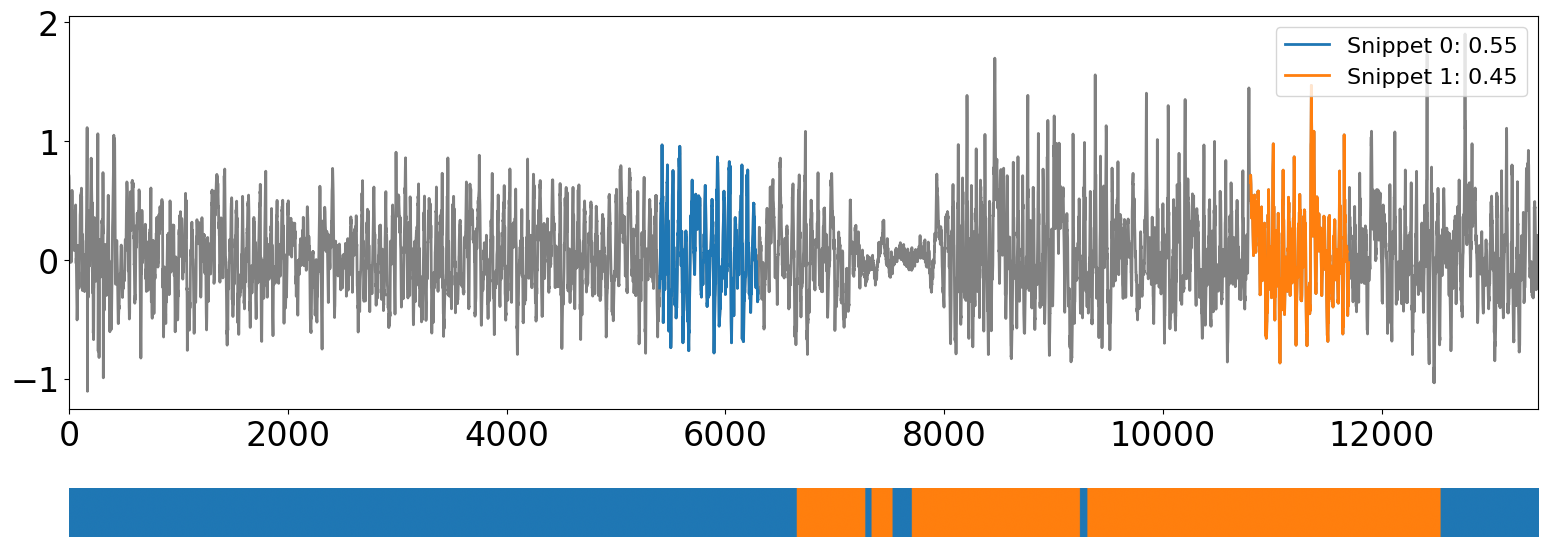

900


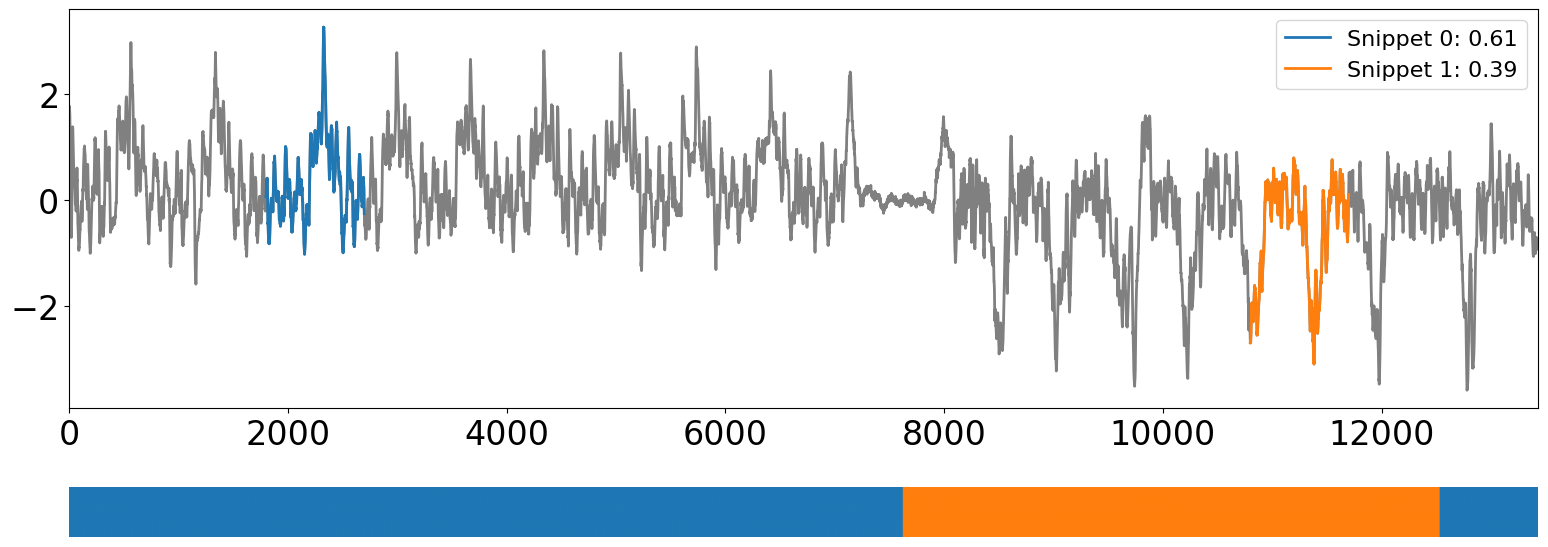

900


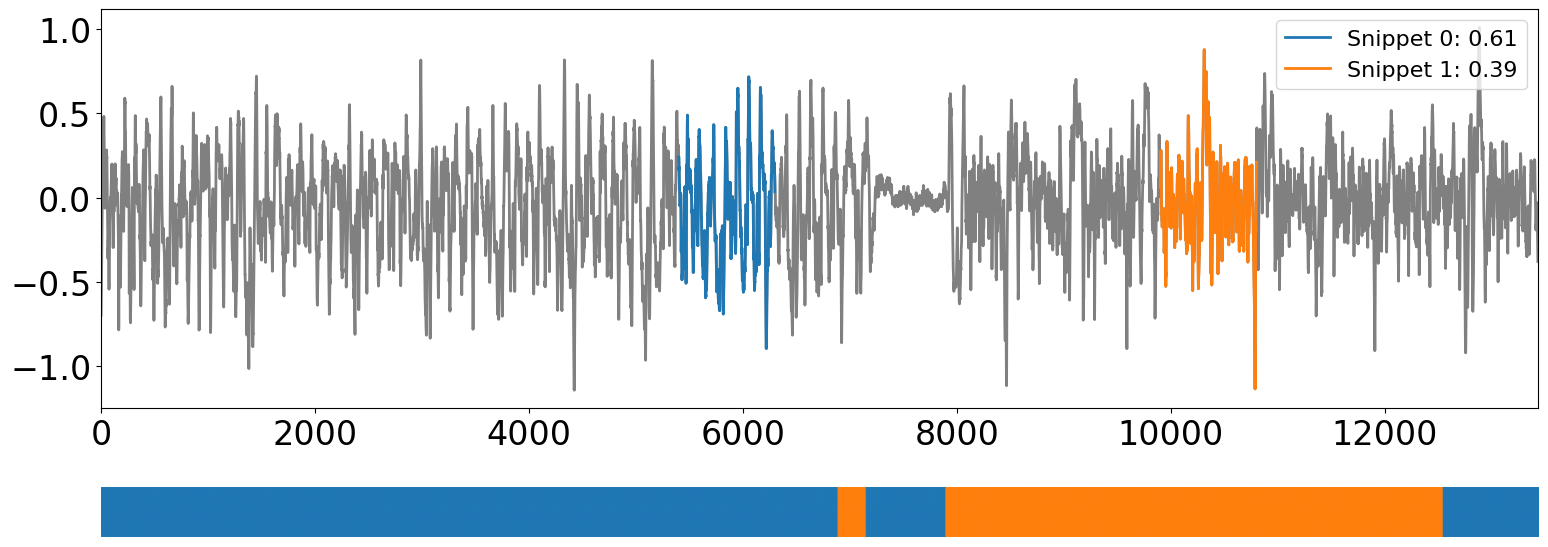

In [12]:
gyroscope_x = pamap[10][interval_mask]
snp_x = snippets(gyroscope_x, 900, 2, percentage=0.5)

plot_snippets(gyroscope_x, snp_x)

snp_activity_ids_x = np.zeros(len(gyroscope_x))
for value, start, end in snp_x[-1]:
    snp_activity_ids_x[start:end] = value


gyroscope_y = pamap[11][interval_mask]

snp_y = snippets(gyroscope_y, 900, 2, percentage=0.5)

plot_snippets(gyroscope_y, snp_y)

snp_activity_ids_y = np.zeros(len(gyroscope_y))
for value, start, end in snp_y[-1]:
    snp_activity_ids_y[start:end] = value


gyroscope_z = pamap[12][interval_mask]

snp_z = snippets(gyroscope_z, 900, 2, percentage=0.5)

plot_snippets(gyroscope_z, snp_z)

snp_activity_ids_z = np.zeros(len(gyroscope_z))
for value, start, end in snp_z[-1]:
    snp_activity_ids_z[start:end] = value

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [13]:
snp_activity_ids = []
for i in range(len(gyroscope_x)):
    votes = [snp_activity_ids_x[i], snp_activity_ids_y[i], snp_activity_ids_z[i]]
    snp_activity_ids.append(np.bincount(votes).argmax())

snp_activity_ids = np.array(snp_activity_ids)

accuracy = accuracy_score(activity_ids, snp_activity_ids)
print(f"{accuracy*100:.2f}%")

C:\Users\admin\AppData\Local\Temp\ipykernel_24348\1570484757.py:4: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  snp_activity_ids.append(np.bincount(votes).argmax())


90.13%


**Выводы:** объединение трёх осей гироскопа и голосование по сниппетам дало более устойчивую и точную разметку (accuracy ≈ **90.13%**) по сравнению с одномерной, которая чаще «рвет» сегменты и ошибается на границах. По каждой оси `snippets(..., m≈900, k=2, percentage≈0.5)` выявили две доминирующие мотивации движений: на X вклад классов распределился ~0.55/0.45, на Y и Z ~0.61/0.39; это видно по окрашенным «синим/оранжевым» кластерам — X сильнее реагирует на эпизоды около 6k и 10–12k отсчётов, Y смещает акценты к 8–11k, Z фиксирует более резкие пики ближе к 11k. При простом голосовании (по осевым меткам `argmax bincount`) несовпадающие осевые ошибки взаимно компенсируются: краткие ложные всплески одной оси «переголосовываются» двумя другими, границы становятся непрерывнее и физически осмысленнее (единые макро-эпизоды вместо набора коротких отрезков), а смещение границ, вызванное большим окном `m` и параметром `percentage`, сглаживается. В сравнении с разметкой по одной оси, многомерный подход устойчив к ориентации датчика и осевому шуму, лучше локализует длительные активности и реже путает переходы; остаточные недочёты — инерция на стыках и редкие пропуски при синхронных слабых сигналах на всех осях — скорее следствие выбранного окна/порога, а не принципиального недостатка метода.

#### **5.1.3.** Задача 3. Подбор оптимального значения $k$

Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [14]:
m_opt = 900
k_max = 9

profile_areas = []
for i in range(3):
    gyroscope = pamap[10 + i][interval_mask]
    _, _, profiles, _, _, _ = snippets(gyroscope, m_opt, k_max, percentage=0.5)
    areas = [
        float(np.sum(np.min(profiles[:k], axis=0)))
        for k in range(1, k_max + 1)
    ]
    profile_areas.append(np.array(areas, dtype=float))

profile_areas = np.vstack(profile_areas).mean(axis=0)
profile_areas

array([199099.14508196, 158733.404929  , 142745.34927286, 127963.12246979,
       113634.47784495, 100481.1636238 ,  88297.16677244,  76730.68022324,
        65747.13183904])

In [15]:
change = np.empty(profile_areas.shape, dtype=profile_areas.dtype)
change[0] = np.nan
change[1:] = profile_areas[:-1] / profile_areas[1:] - 1.0
change

array([       nan, 0.25429896, 0.11200404, 0.11551943, 0.12609417,
       0.13090328, 0.13798854, 0.15074135, 0.16705745])

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

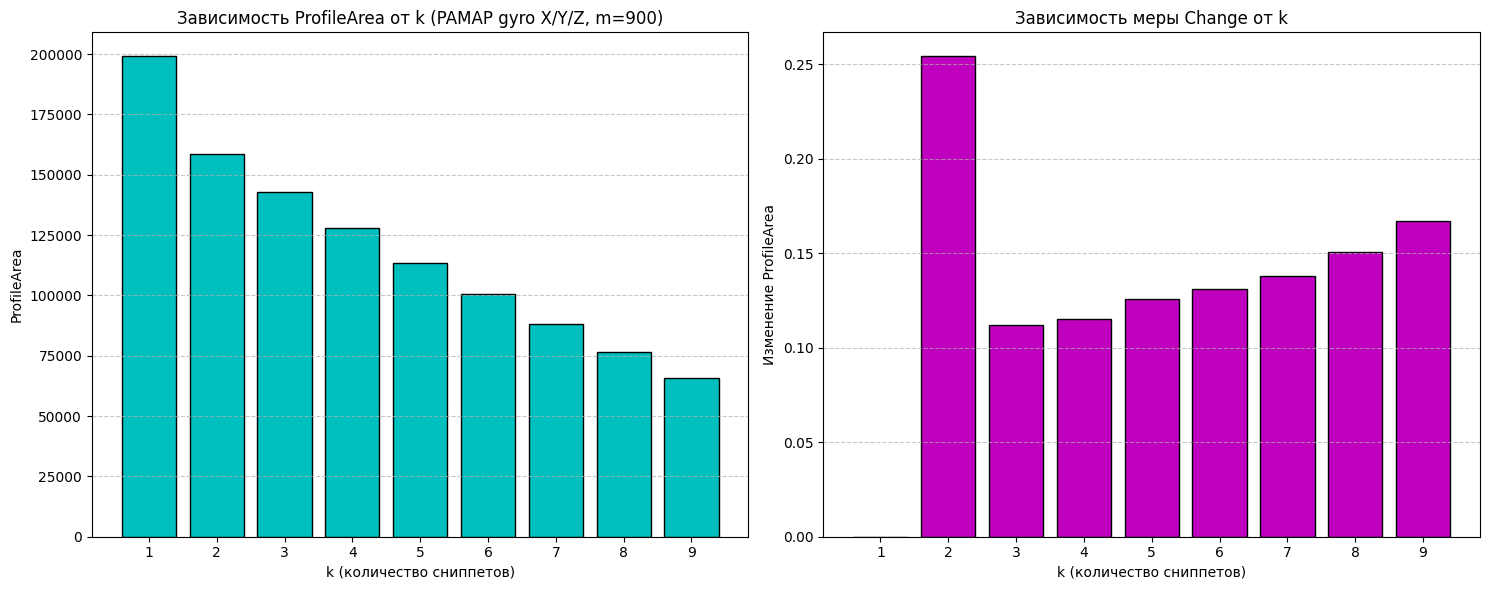

In [16]:
k_values = np.arange(1, k_max + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Зависимость ProfileArea от k
ax1.bar(k_values, profile_areas, color='c', edgecolor='black')
ax1.set_xticks(k_values)
ax1.set_xlabel("k (количество сниппетов)")
ax1.set_ylabel("ProfileArea")
ax1.set_title("Зависимость ProfileArea от k (PAMAP gyro X/Y/Z, m=900)")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# График 2: Зависимость меры Change от k
ax2.bar(k_values, np.nan_to_num(change, nan=0.0), color='m', edgecolor='black')
ax2.set_xticks(k_values)
ax2.set_xlabel("k (количество сниппетов)")
ax2.set_ylabel("Изменение ProfileArea")
ax2.set_title("Зависимость меры Change от k")
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Выводы**: Падение ProfileArea с ростом k показывает, что каждый новый сниппет лучше «покрывает» характерные режимы сигнала, но столбцы change говорят, где это покрытие даёт наибольший **дополнительный** эффект: резко выраженный скачок при переходе от k=1 к k=2 (≈+25%) фиксирует появление второй доминирующей динамики, а дальнейшие приросты монотонны, но заметно меньше (порядка 11–17%) и отражают уже тонкую подстройку границ без качественного изменения структуры поведения. Следовательно, содержательно ряд на выбранном интервале описывается двумя устойчивыми режимами движения, а добавление k>2 даёт убывающую отдачу и приводит скорее к фрагментации. Наилучшим значением является **k=2**.